libraries

In [4]:
!pip install ultralytics xmltodict

In [10]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**mount from drive**

In [ ]:
!mkdir -p /content/dataset/train /content/dataset/val /content/dataset/test

# 2. Unzip the files from your Google Drive folder named "dataset"
!unzip -q "/content/drive/MyDrive/dataset/train.zip" -d /content/dataset/train/
!unzip -q "/content/drive/MyDrive/dataset/val.zip" -d /content/dataset/val/
!unzip -q "/content/drive/MyDrive/dataset/test.zip" -d /content/dataset/test/

print("🎉 Extraction complete! Your data is fully loaded into Colab local memory.")

In [4]:
!ls -F /content/dataset/train/

train/


CONVERT XML TO YOLO ACCEPTABLE PATTERN

In [8]:
import os
import xml.etree.ElementTree as ET
import glob

def convert_bbox(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return (x * dw, y * dh, w * dw, h * dh)

def process_xml_folder(base_split_path):
    # This recursively crawls the folder to find the 'xml' directory regardless of nesting
    xml_search = glob.glob(os.path.join(base_split_path, '**/xml'), recursive=True)
    if not xml_search:
        print(f"⚠️ Could not find an 'xml' folder inside {base_split_path}")
        return

    xml_dir = xml_search[0]
    # The images directory is typically parallel to the xml directory
    img_dir = os.path.abspath(os.path.join(xml_dir, '..', 'images'))

    # If your folder doesn't use parallel naming, default to putting text files right next to XML
    if not os.path.exists(img_dir):
        img_dir = os.path.abspath(os.path.join(xml_dir, '..'))

    xml_files = glob.glob(os.path.join(xml_dir, '*.xml'))
    print(f"Processing {len(xml_files)} XML files. Labels will save to: {img_dir}")

    for xml_file in xml_files:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        size = root.find('size')
        if size is None: continue
        w = int(size.find('width').text)
        h = int(size.find('height').text)
        if w == 0 or h == 0: continue

        filename = os.path.splitext(os.path.basename(xml_file))[0]
        out_file = open(os.path.join(img_dir, f"{filename}.txt"), 'w')

        for obj in root.iter('object'):
            # Maps any target structural annotation class (UAV, drone, drone-body) to Class 0
            xmlbox = obj.find('bndbox')
            b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
                 float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
            bb = convert_bbox((w, h), b)
            out_file.write(f"0 " + " ".join([f"{a:.6f}" for a in bb]) + '\n')
        out_file.close()

# Run optimization parser across splits
for split in ['train', 'val', 'test']:
    print(f"\n--- Scanning Split: {split} ---")
    process_xml_folder(f'/content/dataset/{split}')

print("\n Parsing Complete! All bounding boxes converted to YOLO parameters.")


--- Scanning Split: train ---
Processing 5200 XML files. Labels will save to: /content/dataset/train

--- Scanning Split: val ---
Processing 2600 XML files. Labels will save to: /content/dataset/val

--- Scanning Split: test ---
Processing 2200 XML files. Labels will save to: /content/dataset/test

✅ Parsing Complete! All bounding boxes converted to YOLO parameters.


verifying the directories structure

In [6]:
print("--- TRAIN FOLDER CONTENTS ---")
!ls -R /content/dataset/train | head -n 20

print("\n--- TEST FOLDER CONTENTS ---")
!ls -R /content/dataset/test | head -n 20

--- TRAIN FOLDER CONTENTS ---
/content/dataset/train:
train

/content/dataset/train/train:
00001.txt
00002.txt
00003.txt
00004.txt
00005.txt
00006.txt
00007.txt
00008.txt
00009.txt
00010.txt
00011.txt
00012.txt
00013.txt
00014.txt
00015.txt
00016.txt

--- TEST FOLDER CONTENTS ---
/content/dataset/test:
test

/content/dataset/test/test:
00001.txt
00002.txt
00003.txt
00004.txt
00005.txt
00006.txt
00007.txt
00008.txt
00009.txt
00010.txt
00011.txt
00012.txt
00013.txt
00014.txt
00015.txt
00016.txt


In [10]:
# 1. Move files out of the nested subfolders to the clean split root
!mv /content/dataset/train/train/* /content/dataset/train/ 2>/dev/null
!mv /content/dataset/val/val/* /content/dataset/val/ 2>/dev/null
!mv /content/dataset/test/test/* /content/dataset/test/ 2>/dev/null

# 2. Delete the now-empty duplicate nested folders
!rm -rf /content/dataset/train/train /content/dataset/val/val /content/dataset/test/test

# 3. Print out a quick snapshot to verify images and text files sit together
print("--- Verified Train Folder Split ---")
!ls /content/dataset/train | head -n 10

--- Verified Train Folder Split ---
img
xml


In [9]:
import yaml
import os

# Define the absolute direct paths where your images/labels sit together
data_config = {
    'path': '/content/dataset',
    'train': 'train',
    'val': 'val' if os.path.exists('/content/dataset/val') else 'train', # Fallback to train if val folder name differs
    'test': 'test',
    'names': {0: 'drone'}
}

with open('/content/dataset.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("dataset.yaml generated successfully! Content:")
print(yaml.dump(data_config))

📝 dataset.yaml generated successfully! Content:
names:
  0: drone
path: /content/dataset
test: test
train: train
val: val



In [11]:
import os
import xml.etree.ElementTree as ET
import glob
import yaml

def convert_bbox(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return (x * dw, y * dh, w * dw, h * dh)

def convert_xml_folder(split_path):
    # Target your exact folder structure layout
    xml_dir = os.path.join(split_path, 'xml')
    img_dir = os.path.join(split_path, 'img')

    xml_files = glob.glob(os.path.join(xml_dir, '*.xml'))
    if not xml_files:
        print(f" No XML files found inside {xml_dir}")
        return

    print(f"Parsing {len(xml_files)} files. Labels saving to: {img_dir}")

    for xml_file in xml_files:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        size = root.find('size')
        if size is None: continue
        w = int(size.find('width').text)
        h = int(size.find('height').text)
        if w == 0 or h == 0: continue

        filename = os.path.splitext(os.path.basename(xml_file))[0]
        # YOLO pairs labels directly next to images in the same directory
        out_file = open(os.path.join(img_dir, f"{filename}.txt"), 'w')

        for obj in root.iter('object'):
            xmlbox = obj.find('bndbox')
            b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text),
                 float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
            bb = convert_bbox((w, h), b)
            # Map everything to Class 0 (drone)
            out_file.write(f"0 " + " ".join([f"{a:.6f}" for a in bb]) + '\n')
        out_file.close()

# Loop through your structural dataset splits
for split in ['train', 'val', 'test']:
    print(f"\n--- Processing Split: {split} ---")
    convert_xml_folder(f'/content/dataset/{split}')

print("\nLabel files successfully written directly beside your dataset images!")


--- Processing Split: train ---
Parsing 5200 files. Labels saving to: /content/dataset/train/img

--- Processing Split: val ---
Parsing 2600 files. Labels saving to: /content/dataset/val/img

--- Processing Split: test ---
Parsing 2200 files. Labels saving to: /content/dataset/test/img

✅ Label files successfully written directly beside your dataset images!


In [12]:
import yaml
import os

# Check if the validation parse succeeded, otherwise fall back to training images for safety
val_path = 'val/img' if len(os.listdir('/content/dataset/val/img')) > 0 else 'train/img'

data_config = {
    'path': '/content/dataset',
    'train': 'train/img',
    'val': val_path,
    'test': 'test/img',
    'names': {0: 'drone'}
}

with open('/content/dataset.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("dataset.yaml generated successfully:")
print(yaml.dump(data_config))

📝 dataset.yaml generated successfully:
names:
  0: drone
path: /content/dataset
test: test/img
train: train/img
val: val/img



In [7]:
!rm -rf /content/dataset/val

In [8]:
!mkdir -p /content/dataset/val

# 2. Extract your clean validation zip file from your Drive folder
!unzip -q "/content/drive/MyDrive/dataset/val.zip" -d /content/dataset/val/

In [9]:
print(" Validation contents extracted. Verifying directories:")
!ls -F /content/dataset/val/

📂 Validation contents extracted. Verifying directories:
val/


TRANSFER LEARNING

In [13]:
from ultralytics import YOLO

# 1. Initialize the edge-optimized YOLO26 Nano structure
model = YOLO('yolo26n.pt')

# 2. Fire up the training pipeline on your dataset
results = model.train(
    data='/content/dataset.yaml',
    epochs=50,                  # Ideal limit to achieve solid accuracy baseline convergence
    imgsz=640,                  # Standard resolution for edge deployment pipelines
    batch=32,                   # Handled easily by YOLO26's lightweight memory architecture
    device=0,                   # Formally directs processes onto the active T4 GPU instance
    optimizer='MuSGD',          # Employs native stable convergence parameters
    name='yolo26_drone_baseline'
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_drone_baseline-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=MuSGD, overlap_mask=True, patie

In [14]:
drive_runs_dir = '/content/drive/MyDrive/drone_project_runs'
os.makedirs(drive_runs_dir, exist_ok=True)

INFERENCE


image 1/1 /content/dataset/val/img/00123.jpg: 384x640 1 drone, 61.9ms
Speed: 1.6ms preprocess, 61.9ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


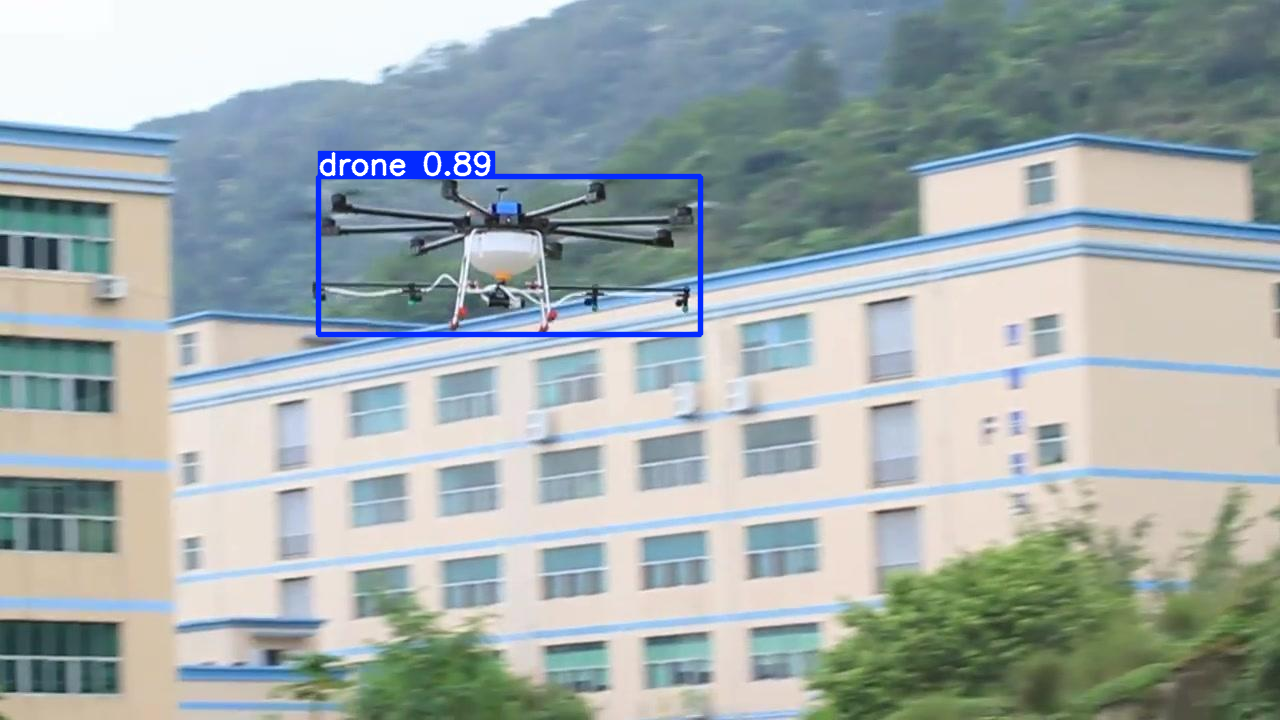

In [17]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# 1. Load your newly generated PyTorch baseline weights
model = YOLO('/content/runs/detect/yolo26_drone_baseline-3/weights/best.pt')

# 2. Run inference on a test image (Replace with a path to one of your actual validation images)
test_image_path = '/content/dataset/val/img/00123.jpg'

results = model.predict(source=test_image_path, conf=0.25, imgsz=640)

# 3. Visualize the output bounding box
for r in results:
    im_bgr = r.plot()  # Plots the boxes directly onto the image array
    cv2_imshow(im_bgr) # Displays it inside your Colab cell

In [18]:
drive_runs_dir = '/content/drive/MyDrive/drone_project_runs'
os.makedirs(drive_runs_dir, exist_ok=True)

In [2]:
# 1. Clear out previous workspace directories
!rm -rf /content/dataset /content/dataset.yaml

# 2. Re-create explicit directory structures
!mkdir -p /content/dataset/train /content/dataset/val /content/dataset/test

# 3. Unzip files directly from your Drive 'dataset' folder
!unzip -q "/content/drive/MyDrive/dataset/train.zip" -d /content/dataset/train/
!unzip -q "/content/drive/MyDrive/dataset/val.zip" -d /content/dataset/val/
!unzip -q "/content/drive/MyDrive/dataset/test.zip" -d /content/dataset/test/

print("--- Train directory verification ---")
!ls -F /content/dataset/train/

--- Train directory verification ---
train/


**QUANTIZATION**

In [19]:
from ultralytics import YOLO

# 1. Load your newly minted best weights
model = YOLO('/content/runs/detect/yolo26_drone_baseline-3/weights/best.pt')

# 2. Export to the optimized ONNX format for edge deployment
model.export(format='onnx', half=True)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/runs/detect/yolo26_drone_baseline-3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 310ms
Prepared 4 packages in 1.81s
Installed 4 packages in 250ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: converting to FP16...
ONNX: export success ✅ 5.2s, saved as '/content/runs/detect/yolo26_drone_baseline-3/weights/best.onnx' (4.7 MB)

Export complete (5.7s)
Results saved to /content/runs/detect/yolo26_drone_baseline-3/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/yolo26_drone_baseline-3/weights/best.onnx imgsz=640 half
Validate:        yolo val task=detect model=/content/runs/detect/yolo26_drone_baseline-3/weights/best.onnx imgsz=640 data=/content/dataset.yaml half 
Visualize:       https://netron.app


'/content/runs/detect/yolo26_drone_baseline-3/weights/best.onnx'

In [21]:
drive_runs_dir = '/content/drive/MyDrive/drone_project_runs'
os.makedirs(drive_runs_dir, exist_ok=True)

PRUNING TEST